In this notebook:
1. **Feature Scaling for Linear Logistic Regression**
2. **Feature Scaling for Polynomial Logistic Regression**

Output:
1. X Train Set after Dropping Outliers for Linear Logistic Regression and Polynomial Logistic Regression
2. y Train Set after Dropping Outliers for Linear Logistic Regression and Polynomial Logistic Regression
3. X Test Set for Linear Logistic Regression and Polynomial Logistic Regression
4. y Test Set for Linear Logistic Regression and Polynomial Logistic Regression

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.4f}'.format

In [38]:
train_data = pd.read_csv("../data/linear/train_set.csv", index_col=0, parse_dates=True)
test_data = pd.read_csv("../data/linear/test_set.csv", index_col=0, parse_dates=True)

train_data.head()

,close,volume,pct_change_1d,rsi,adx,corr,volatility,signal
Date,,,,,,,,
2023-02-02,1.7050,8523200,-0.0263,25.7175,20.0382,0.6622,1.5033,1
2023-02-03,1.7511,9219400,0.0270,39.1584,23.3034,0.7018,1.8069,0
2023-02-07,1.6866,11662300,-0.0368,30.5575,27.4842,0.8373,2.0947,1
2023-02-08,1.7050,5665300,0.0109,35.0839,31.2470,0.8722,2.1606,1
2023-02-09,1.7142,6074700,0.0054,37.3526,33.7872,0.8379,2.1827,0


In [39]:
# exclude 'close' column for feature set X and separate 'signal' column out as target y
X_train = train_data.iloc[:, 1:-1].copy()
y_train = pd.DataFrame(train_data['signal'])
X_test = test_data.iloc[:, 1:-1].copy()
y_test = pd.DataFrame(test_data['signal'])

print(f"X_train.shape: {X_train.shape}, y_train.shape: {y_train.shape}\n"
      f"X_test.shape: {X_test.shape}, y_test.shape: {y_test.shape}\n")

X_train.shape: (572, 6), y_train.shape: (572, 1)
X_test.shape: (144, 6), y_test.shape: (144, 1)



## 1 Feature Scaling for Linear Logistic Regression

- The need for feature scaling
- Visualizing the feature set
- Z-score normalization

#### The need for feature scaling

In [40]:
print(f"\nrange: \n{X_train.max() - X_train.min()}") # range
print(f"\nstandard deviation: \n{X_train.std()}") # standard deviation


range: 
volume          97905800.0000
pct_change_1d          0.2172
rsi                   74.1812
adx                   56.3675
corr                   1.7583
volatility             4.7480
dtype: float64

standard deviation: 
volume          8509350.7945
pct_change_1d         0.0206
rsi                  13.3768
adx                  12.0253
corr                  0.4402
volatility            0.8115
dtype: float64


From above, the range and standard deviation gives us some initial information on the distribution of the data.

Other than *volume*, *rsi* and *adx*, the rest of the base features seem to lie between comparable ranges. This is important as we know that logistic regression will be used as our classification model from the onset. Features with widely different scales forces the learned parameters of the model to fit both large and small scale values together, leading to unstable coefficients, and bad generalization to unseen data.

For example, imagine $x_1$ were *volume* and $x_2$ were *corr* where $-40,000,000<x_1<40,000,000$ and $-1<x_2<1$. The learned parameter for $x_1$ would be extremely small and the parameter for $x_2$ will be comparatively large to compensate for the massive difference in scale. Two new test samples with slight difference in $x_2$ values would lead to vastly different outcomes for the logistic function. If we were to plot a contour plot for $x_1$ and $x_2$, it would have an elongated oval shape and not the ideal circle that is desired.

It also makes gradient descent work less well due to path instability and slow convergence.

Therefore, feature scaling is necessary here.
___

#### Visualizing the feature set

We have an initial idea of the distribution of the data from the range and standard deviation, let us now visualize the data via a histogram plot to see how it is actually distributed across its range.

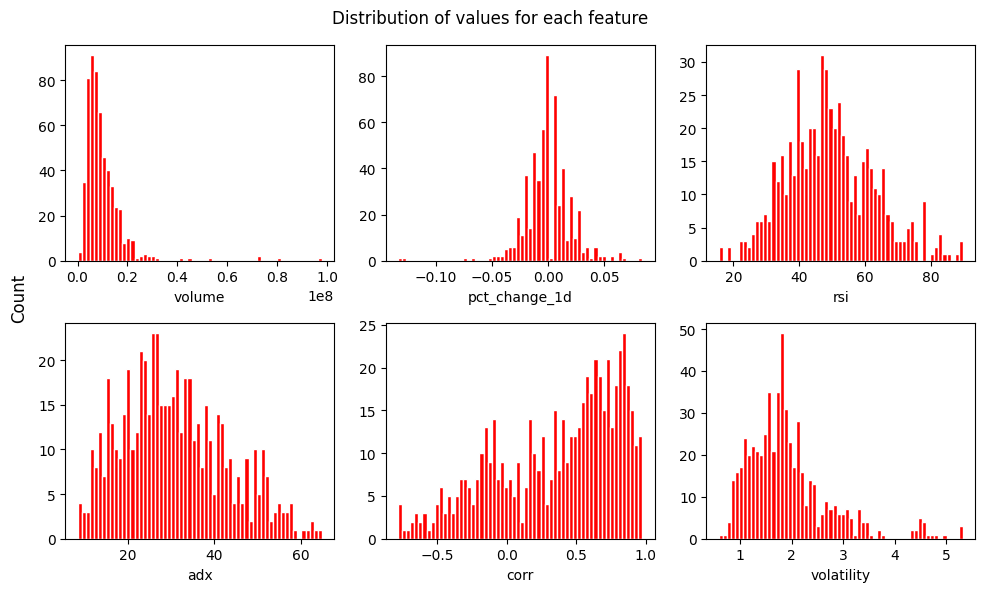

In [41]:
ncolumns = 3
nrows = (X_train.shape[1] + ncolumns-1) // ncolumns
features = X_train.columns

fig, axs = plt.subplots(nrows, ncolumns, figsize=(10, 6))

n=0
for i in range(nrows):
    for j in range(ncolumns):
        axs[i, j].hist(X_train[features[n]], bins=60, color='r', edgecolor='w')
        axs[i, j].set_xlabel(features[n])
        n += 1

fig.supylabel('Count')
fig.suptitle('Distribution of values for each feature')

plt.tight_layout()
plt.show()

From above, we can see that most features are evenly distributed across its range except for *volume* and to a lesser extent *volatility*. They are both right-skewed and *volume* has large outliers that stand out visually.
___

#### Z-score normalization for features 'volume', 'rsi' and 'adx'

<u>**Justifications**</u>

**Z-score normalization instead of min-max normalization**:  
Both Z-score normalization and min-max normalization are sensitive to outliers but Z-score is much less so and does not ruin the scaling for the rest of the data. Z-score normalization also centers the data around a mean of 0.

**Features chosen for normalization**:  
I chose an arbitrary range of $-5<x<5$ to work with for simplicity. *volume*, *rsi* and *adx* have ranges exceeding 10, and *pct_change_1d* has a small range of $-0.10<x<0.10$ and as such I have decided to normalize them.

In [42]:
def zscore_normalize_features(X: pd.DataFrame, columns: list):
    """
    computes Z-score normalized features by column
    
    Args:
      X (DataFrame (m,n)) : input data, m examples, n features
      columns (list (p))  : names of features to be normalized
      
    Returns:
      X_norm (DataFrame (m,n)) : input with selected columns normalized
      mu (Series (p,1))     : mean of each normalized feature
      sigma (Series (p,1))  : standard deviation of each normalized feature
    """
    
    X_norm = X.copy()
    mu = {}
    sigma = {}

    for feature in columns:
        mu[feature] = X[feature].mean()
        sigma[feature] = X[feature].std()
        X_norm[feature] = (X[feature] - mu[feature]) / sigma[feature]
    
    mu = pd.Series(mu)
    sigma = pd.Series(sigma)
    
    return X_norm, mu, sigma

In [43]:
columns_for_scaling = ['volume', 'pct_change_1d', 'adx', 'rsi']

X_train_norm, X_train_mu, X_train_sigma = zscore_normalize_features(X_train, columns_for_scaling)

As only *volume* from our histogram plots earlier show that it is highly right-skewed, I chose to manually drop data points with *volume* above 5 standard deviations from the mean. Although *volatility* is also right-skewed, I made the judgement that it is still acceptable.

If we were to develop a real world application such as a trading algorithm, samples with outliers would be required to be dealt with. Here, we ignore them for now in order to not skew the model.

In [44]:
above = X_train_norm[X_train_norm['volume'] > 5]
print("Length of entries above threshold:", len(above))

m = len(X_train_norm)
X_train_norm.drop(above.index, inplace=True)
print(f"Length of training set.\nBefore: {m}, After: {len(X_train_norm)}\n")

Length of entries above threshold: 5
Length of training set.
Before: 572, After: 567



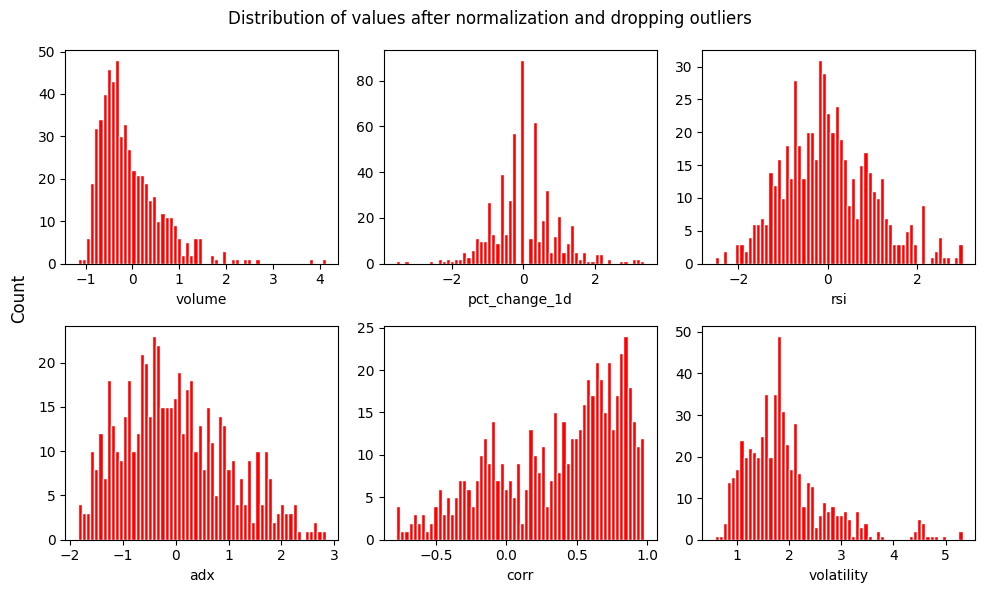

In [45]:
ncolumns = 3
nrows = (X_train_norm.shape[1] + ncolumns-1) // ncolumns
features = X_train_norm.columns

fig, axs = plt.subplots(nrows, ncolumns, figsize=(10, 6))

n=0
for i in range(nrows):
    for j in range(ncolumns):
        axs[i, j].hist(X_train_norm[features[n]], bins=60, color='r', edgecolor='w')
        axs[i, j].set_xlabel(features[n])
        n += 1

fig.supylabel('Count')
fig.suptitle('Distribution of values after normalization and dropping outliers')

plt.tight_layout()
plt.show()

As shown above, the histogram plots now show data that are generally distributed over the same range $-2<x<5$.

In [46]:
# Resave original training set without dropped entries
X_train_save = X_train.drop(index=above.index)
y_train_save = y_train.drop(index=above.index)

X_train_save.to_csv("../data/linear/X_train.csv")
y_train_save.to_csv("../data/linear/y_train.csv")
X_test.to_csv("../data/linear/X_test.csv")
y_test.to_csv("../data/linear/y_test.csv")

The process is repeated for the polynomial feature set below.
___

## 2 Feature Scaling for Polynomial Logistic Regression

- Visualizing the feature set
- Z-score normalization

In [47]:
train_poly_data = pd.read_csv("../data/poly/train_poly_set.csv", index_col=0, parse_dates=True)
test_poly_data = pd.read_csv("../data/poly/test_poly_set.csv", index_col=0, parse_dates=True)

train_poly_data.head(5)

,close,volume,pct_change_1d,rsi,adx,corr,volatility,volume^2,pct_change_1d^2,rsi^2,...,pct_change_1d*adx,pct_change_1d*corr,pct_change_1d*volatility,rsi*adx,rsi*corr,rsi*volatility,adx*corr,adx*volatility,corr*volatility,signal
Date,,,,,,,,,,,,,,,,,,,,,
2023-02-02,1.7050,8523200,-0.0263,25.7175,20.0382,0.6622,1.5033,72644938240000,0.0007,661.3887,...,-0.5273,-0.0174,-0.0396,515.3315,17.0313,38.6607,13.2702,30.1231,0.9955,1
2023-02-03,1.7511,9219400,0.0270,39.1584,23.3034,0.7018,1.8069,84997336360000,0.0007,1533.3808,...,0.6298,0.0190,0.0488,912.5240,27.4803,70.7540,16.3537,42.1061,1.2680,0
2023-02-07,1.6866,11662300,-0.0368,30.5575,27.4842,0.8373,2.0947,136009241290000,0.0014,933.7604,...,-1.0126,-0.0308,-0.0772,839.8490,25.5844,64.0078,23.0113,57.5703,1.7538,1
2023-02-08,1.7050,5665300,0.0109,35.0839,31.2470,0.8722,2.1606,32095624090000,0.0001,1230.8832,...,0.3415,0.0095,0.0236,1096.2669,30.6019,75.8037,27.2551,67.5134,1.8846,1
2023-02-09,1.7142,6074700,0.0054,37.3526,33.7872,0.8379,2.1827,36901980090000,0.0000,1395.2168,...,0.1826,0.0045,0.0118,1262.0385,31.2961,81.5298,28.3088,73.7475,1.8288,0


In [48]:
# exclude 'close' signal for feature set X and separate 'signal' column out as target y
X_poly_train = train_poly_data.iloc[:, 1:-1].copy()
y_poly_train = pd.DataFrame(train_poly_data['signal'])
X_poly_test = test_poly_data.iloc[:, 1:-1].copy()
y_poly_test = pd.DataFrame(test_poly_data['signal'])

print(f"X_poly_train.shape: {X_poly_train.shape}, y_poly_train.shape: {y_poly_train.shape}\n"
      f"X_poly_test.shape : {X_poly_test.shape}, y_poly_test.shape : {y_poly_test.shape}\n")

feature_range = X_poly_train.max() - X_poly_train.min()
std = X_poly_train.std()
print(f"\nrange: \n{feature_range}")
print(f"\nstandard deviation: \n{std}")

X_poly_train.shape: (572, 27), y_poly_train.shape: (572, 1)
X_poly_test.shape : (144, 27), y_poly_test.shape : (144, 1)


range: 
volume                             97905800.0000
pct_change_1d                             0.2172
rsi                                      74.1812
adx                                      56.3675
corr                                      1.7583
volatility                                4.7480
volume^2                   9585545673640000.0000
pct_change_1d^2                           0.0178
rsi^2                                  7804.1031
adx^2                                  4128.7378
corr^2                                    0.9531
volatility^2                             28.0267
volume*pct_change_1d               14798048.5038
volume*rsi                       4082819688.2311
volume*adx                       4073941299.6596
volume*corr                        86668499.8797
volume*volatility                 431128765.6223
pct_change_1d*rsi                    

A quick calculation of the range and standard deviation above show us that many features have scales of vastly different magnitudes and thus feature scaling would definitely be required here.

#### Visualizing the feature set

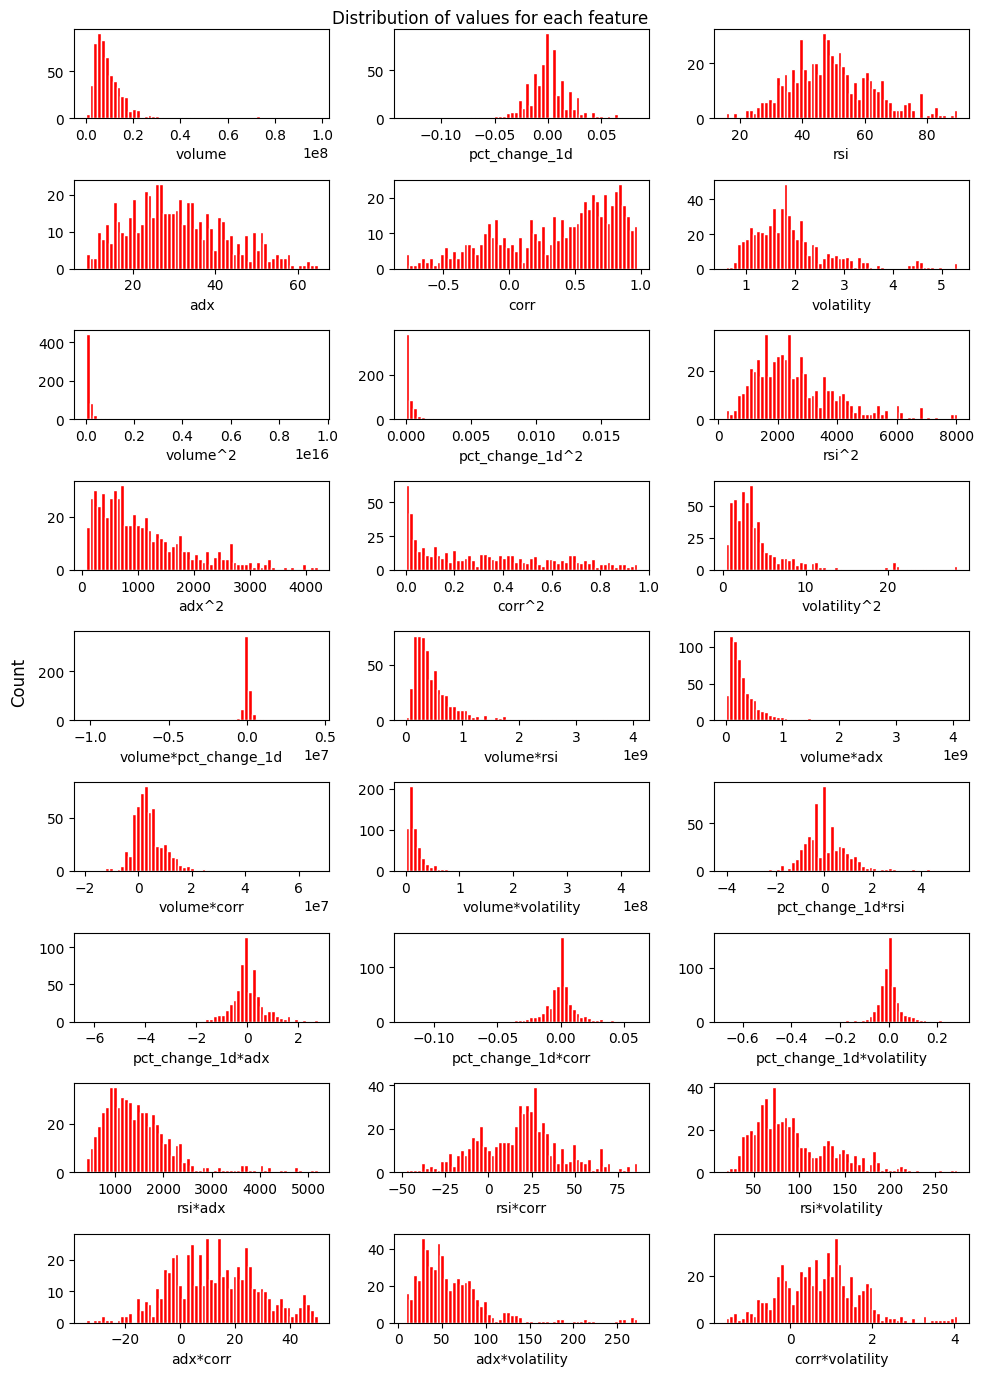

In [49]:
ncolumns = 3
nrows = (X_poly_train.shape[1] + ncolumns-1) // ncolumns
features2 = X_poly_train.columns

fig, axs = plt.subplots(nrows, ncolumns, figsize=(10, 14))

n=0
for i in range(nrows):
    for j in range(ncolumns):
        axs[i, j].hist(X_poly_train[features2[n]], bins=60, color='r', edgecolor='w')
        axs[i, j].set_xlabel(features2[n])
        n += 1

fig.supylabel('Count')
fig.suptitle('Distribution of values for each feature')

plt.tight_layout()
plt.show()

As the number of features get larger, it gets impractical to manually analyze each feature and decide how best to process it. 

Here with 27 features, I plot the distribution of the data to get an overview of the data, and to give me ideas on how I would want to process it. Histogram visualizations allow any interesting outliers or patterns in the data to be spotted easily for further inspection.
___

#### Z-score normalization

After inspection, I decided to apply Z-score normalization to any feature with a range above 10 or below 1. Our aim here is to get data values to fall between $-5<x<5$ which  gives gradient descent a comparable range of values to work with.

In [50]:
columns_for_scaling2 = []

for name in feature_range.index:
    if feature_range[name] > 5 or feature_range[name] < 0.5:
        columns_for_scaling2.append(name)
    else:
        print(name, "is in acceptable range")
print(f"\ncolumns: {columns_for_scaling2}\nlength: {len(columns_for_scaling2)}")

corr is in acceptable range
volatility is in acceptable range
corr^2 is in acceptable range
pct_change_1d*volatility is in acceptable range

columns: ['volume', 'pct_change_1d', 'rsi', 'adx', 'volume^2', 'pct_change_1d^2', 'rsi^2', 'adx^2', 'volatility^2', 'volume*pct_change_1d', 'volume*rsi', 'volume*adx', 'volume*corr', 'volume*volatility', 'pct_change_1d*rsi', 'pct_change_1d*adx', 'pct_change_1d*corr', 'rsi*adx', 'rsi*corr', 'rsi*volatility', 'adx*corr', 'adx*volatility', 'corr*volatility']
length: 23


23 features were found above to have a range above 10 or below 1. We normalize them.

In [51]:
X_poly_train_norm, X_poly_train_mu, X_poly_train_sigma = zscore_normalize_features(X_poly_train, columns_for_scaling2)

After normalization, any entries for all features with values above $z>|5|$ is removed for simplicity.

Outliers may tell us a story about our data which we otherwise would not know so it is not always wise to remove them.

For a more advanced project, manual investigation might reveal interesting facts about our data or using methods such as log transformations to incorporate outliers in our model.

In [52]:
above2 = X_poly_train_norm[(X_poly_train_norm.abs() > 5).any(axis=1)] # entries above zscore threshold of 5

print("Length of entries above threshold:", len(above2))
print(above2.index)

m = len(X_poly_train_norm)
X_poly_train_norm.drop(above2.index, inplace=True)
print(f"\nLength of training set:\nBefore: {m}, After: {len(X_poly_train_norm)}\n")

Length of entries above threshold: 10
DatetimeIndex(['2023-05-31', '2023-08-10', '2024-03-15', '2024-05-02',
               '2024-05-07', '2024-11-15', '2025-02-19', '2025-02-28',
               '2025-03-03', '2025-03-04'],
              dtype='datetime64[us]', name='Date', freq=None)

Length of training set:
Before: 572, After: 562



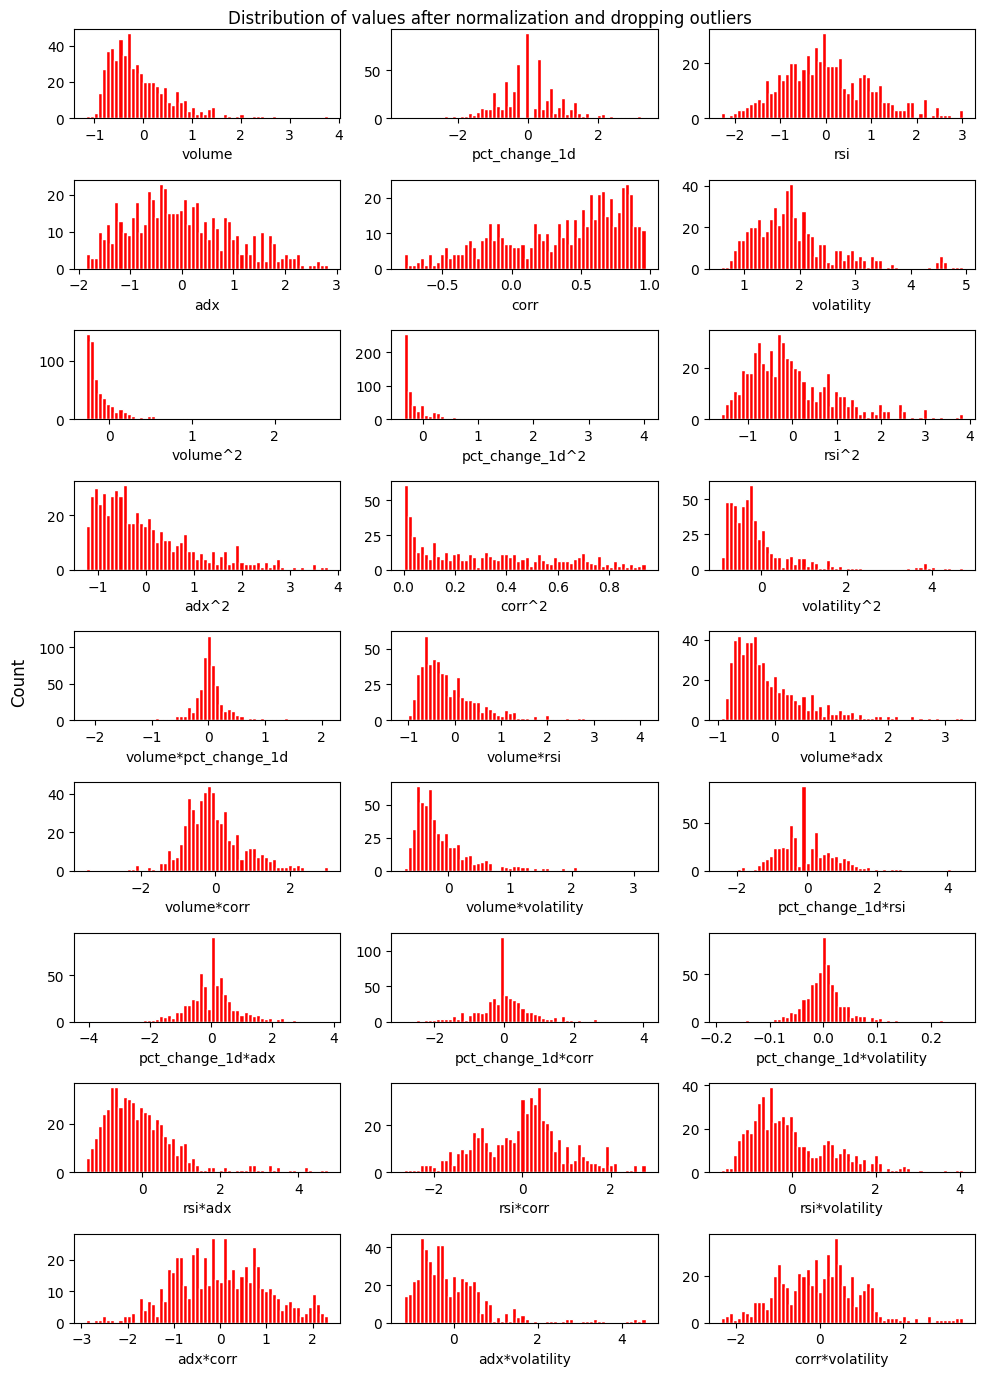

In [53]:
ncolumns = 3
nrows = (X_poly_train_norm.shape[1] + ncolumns-1) // ncolumns
features2 = X_poly_train_norm.columns

fig, axs = plt.subplots(nrows, ncolumns, figsize=(10, 14))

n=0
for i in range(nrows):
    for j in range(ncolumns):
        axs[i, j].hist(X_poly_train_norm[features2[n]], bins=60, color='r', edgecolor='w')
        axs[i, j].set_xlabel(features2[n])
        n += 1

fig.supylabel('Count')
fig.suptitle('Distribution of values after normalization and dropping outliers')

plt.tight_layout()
plt.show()

The feature values are now more comparable with *pct_change_1d\*volatility* being the most tightly bounded feature with values between $-0.2<x<0.2$.

Although again, some features such as *volume^2* and *pct_change_1d^2* are highly right-skewed which makes the learned parameter $w_j$ for these features to be numerically instable and not representative of the general population. In this simple ML workflow, we will leave them be.

In [54]:
feature_range = X_poly_train_norm.max() - X_poly_train_norm.min()
std = X_poly_train_norm.std()
print(f"\nrange: \n{feature_range}")
print(f"\nstandard deviation: \n{std}")


range: 
volume                     4.9565
pct_change_1d              6.8928
rsi                        5.3255
adx                        4.6874
corr                       1.7523
volatility                 4.3668
volume^2                   2.9304
pct_change_1d^2            4.3816
rsi^2                      5.4458
adx^2                      5.0353
corr^2                     0.9414
volatility^2               5.6613
volume*pct_change_1d       4.2694
volume*rsi                 5.2221
volume*adx                 4.2519
volume*corr                6.4939
volume*volatility          3.9189
pct_change_1d*rsi          6.9009
pct_change_1d*adx          7.9165
pct_change_1d*corr         6.9482
pct_change_1d*volatility   0.4506
rsi*adx                    6.1921
rsi*corr                   5.4753
rsi*volatility             5.7702
adx*corr                   5.2356
adx*volatility             5.7584
corr*volatility            5.7803
dtype: float64

standard deviation: 
volume                     0.6364
pc

A quick sanity check for the ranges and standard deviations for the features above show that the values are comparable and are as expected.

*pct_change_1d\*volatility* has a range of 0.45 which could have been caused by dropping the outliers.

In [55]:
# Resave original unnormalized training set after dropping entries
X_poly_train_save = X_poly_train.drop(index=above2.index)
y_poly_train_save = y_poly_train.drop(index=above2.index)

X_poly_train_save.to_csv("../data/poly/X_poly_train.csv")
y_poly_train_save.to_csv("../data/poly/y_poly_train.csv")
X_poly_test.to_csv("../data/poly/X_poly_test.csv")
y_poly_test.to_csv("../data/poly/y_poly_test.csv")